---
title: "Airbnb in NYC"
subtitle: "DATA 608 Spring 2025 - Story 4"
author: "Stephanie Chiang"
format: revealjs
jupyter: python3
execute:
  echo: false
  output: true
---

## Introduction / OPENING

Assignment
The goal of this assignment is to tell a visual story about the factors that differentiate profitable airbnbs from unprofitable airbnbs. You should imagine that you are either an analyst at airbnb looking for ways to help hosts become more profitable or to suggest to make suggestions about who should become a host, or a real estate investor looking to either acquire (or help manage) short term rental properties.
• You could identify listings which are underperforming and the factors that they could change to improve their revenue
• You could identify neighborhoods where new airbnbs are likely to be successful and the characteristics that you would look for in a property.


## The question / CHALLENGE
The Data: https://insideairbnb.com/

the nightly price of the listing
the modeled occupancy rate
information about the location
amenities of the listing
information about the host and other properties that they manage
information about the satisfaction of the guests that stay at the listing

occupancy: fraction of nights in the past year where this airbnb was booked
revenue: equal to the revenue per night
occupancy_level: 
- low 33% or less occupancy
- medium 33% to 66% occupancy
- high greater than 66% occupancy
borough: location of listing

In [3]:
#| output: false

import pandas as pd

# import the data
ab_raw = pd.read_csv("nyc_airbnb_listings.csv")
ab_raw.columns

/var/folders/8g/v1hprjvn28l43wv8d77g185h0000gn/T/ipykernel_16019/1521031938.py:6: DtypeWarning: Columns (13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  ab_raw = pd.read_csv("nyc_airbnb_listings.csv")


Index(['...1', 'id', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighborhood',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated',
       'has_availability', 'number_of_reviews', 'number_of_reviews_ltm',
       'first_review', 'last_review', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_co

In [62]:
#| output: false

ab_raw.head()

,...1,id,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,...,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_per_accommodates,neighbourhood_group,occupancy_level,occupancy,revenue
0,0,2595.0,2845,2008-09-09,"Woodstock, NY",a few days or more,43%,21%,False,Midtown,...,3,3,0,0,0.28,NaN,Manhattan,14.333333333333334,0.477778,NaN
1,1,5136.0,7378,2009-02-03,"New York, NY",within an hour,100%,100%,False,Greenwood Heights,...,1,1,0,0,0.03,53.75,Brooklyn,High,0.927778,199.472222
2,2,6848.0,15991,2009-05-06,"New York, NY",within an hour,100%,100%,True,Williamsburg,...,1,1,0,0,1.05,27.00,Brooklyn,High,0.894872,72.484615
3,3,6872.0,16104,2009-05-07,"New York, NY",within a day,50%,0%,False,East Harlem,...,2,0,2,0,0.04,65.00,Manhattan,3.6153846153846154,0.120513,7.833333
4,4,6990.0,16800,2009-05-12,"New York, NY",within an hour,100%,100%,True,East Harlem,...,1,0,1,0,1.38,65.00,Manhattan,High,0.815385,53.000000


In [ ]:
#| output: false

# clean and tidy

# Sort revenue by descending order and drop highest outliers,
# since 2 rows are throwing off the data
ab = ab_raw.sort_values(by="revenue", ascending=False)
print(ab["revenue"].head())
ab = ab[ab["revenue"] < 4000]

8200     22592.592593
28483     9636.030769
19525     2934.615385
21230     2871.794872
10565     2522.446154
Name: revenue, dtype: float64


In [ ]:
# print amenities
print(ab["amenities"].iloc[0])

# add a column that counts the length of amenities array
ab["num_amenities"] = ab["amenities"].apply(lambda x: len(x.split(",")))
ab["num_amenities"].head()

["Self check-in", "Smoke alarm", "Fire extinguisher", "Kitchen", "Pets allowed", "Dryer", "Private entrance", "Washer", "Keypad", "Carbon monoxide alarm", "Cooking basics", "Iron", "Essentials", "TV"]


19525    14
21230    52
10565    26
35824    19
23755    37
Name: num_amenities, dtype: int64

## ACTION / PLOTS

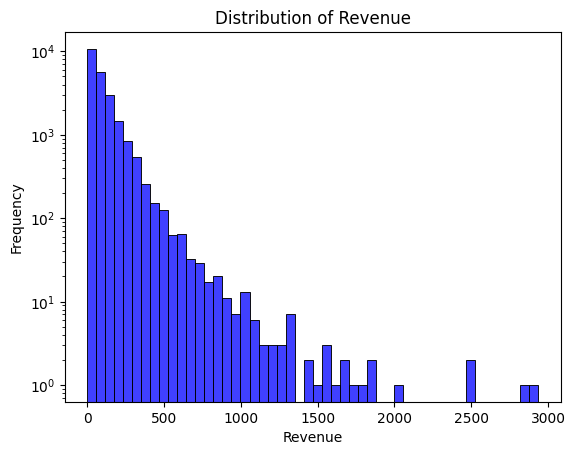

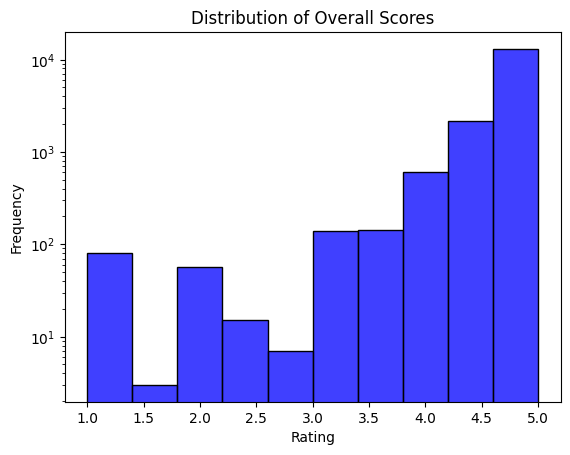

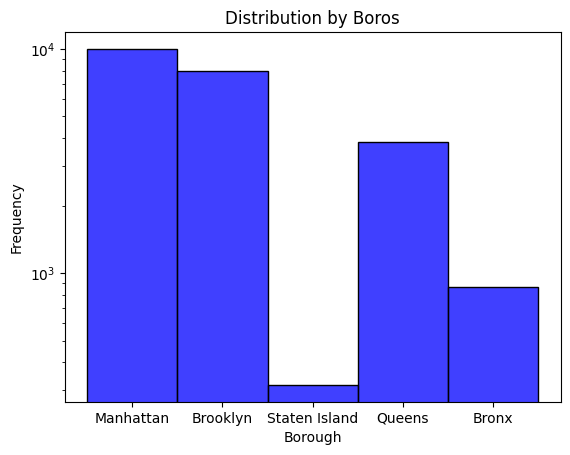

In [ ]:
#| output-location: slide

import matplotlib.pyplot as plt
import seaborn as sns

# Overall distributions of revenue, rating and boro

sns.histplot(ab['revenue'], bins=50, color='blue')
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

sns.histplot(ab['review_scores_rating'], bins=10, color='blue')
plt.title('Distribution of Overall Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

sns.histplot(ab['neighbourhood_group_cleansed'], bins=30, color='blue')
plt.title('Distribution by Borough')
plt.xlabel('Borough')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

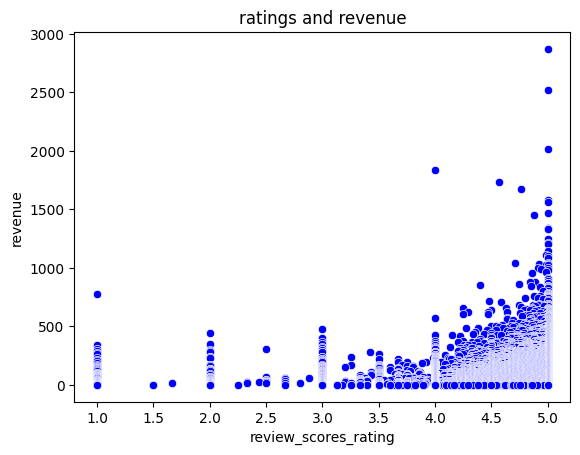

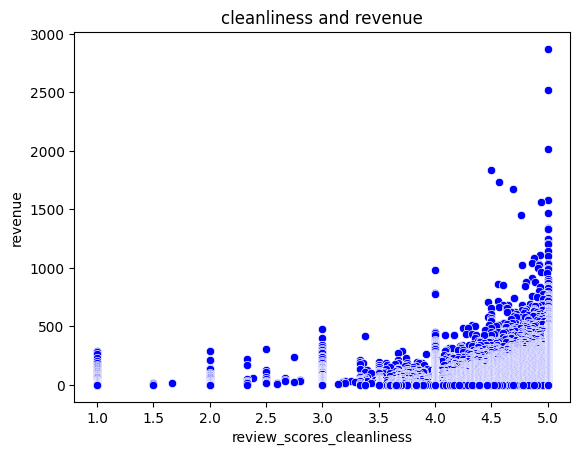

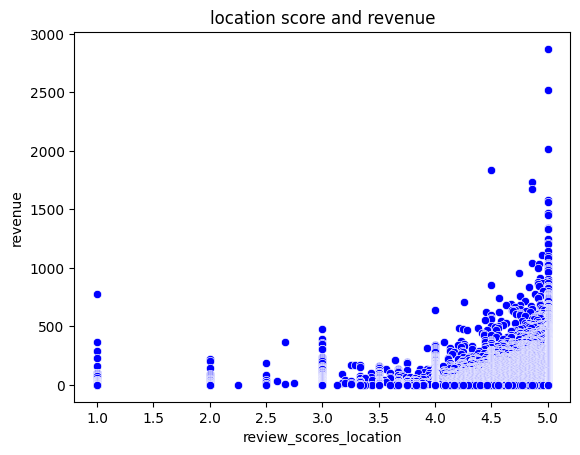

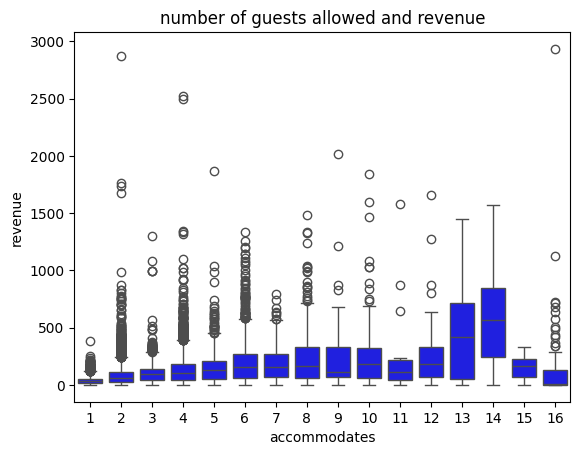

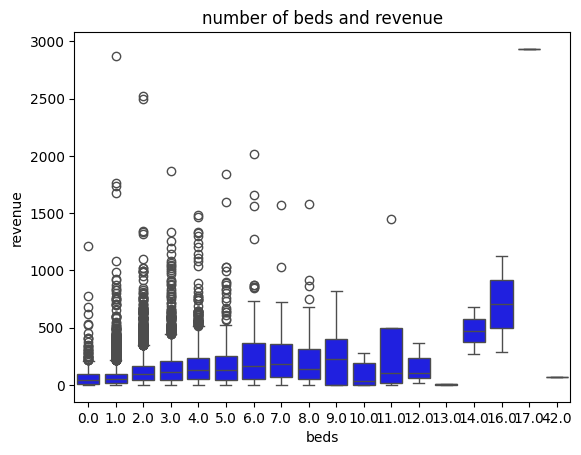

In [77]:
# Relationships between various columns and revenue

sns.scatterplot(data=ab, x='review_scores_rating', y='revenue', color='blue')
plt.title('ratings and revenue')
# plt.yscale('log')
plt.show()

sns.scatterplot(data=ab, x='review_scores_cleanliness', y='revenue', color='blue')
plt.title('cleanliness and revenue')
# plt.yscale('log')
plt.show()

sns.scatterplot(data=ab, x='review_scores_location', y='revenue', color='blue')
plt.title('location score and revenue')
# plt.yscale('log')
plt.show()

sns.boxplot(data=ab, x='accommodates', y='revenue', color='blue')
plt.title('number of guests allowed and revenue')
# plt.yscale('log')
plt.show()

sns.boxplot(data=ab, x='beds', y='revenue', color='blue')
plt.title('number of beds and revenue')
# plt.yscale('log')
plt.show()

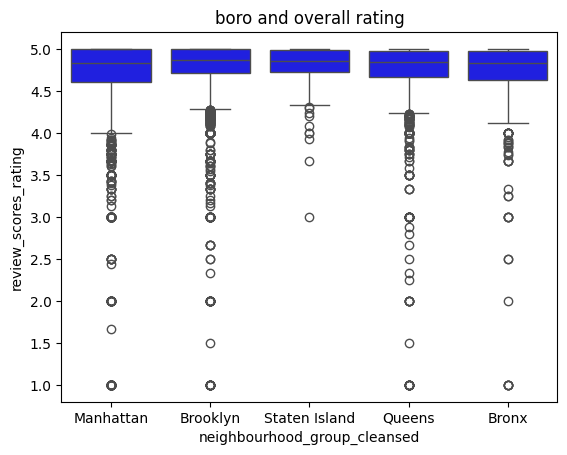

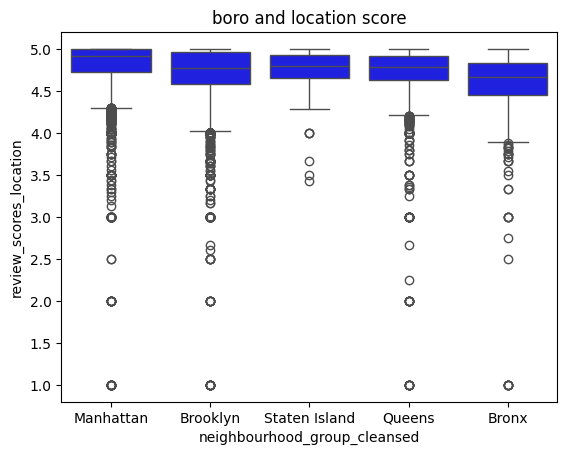

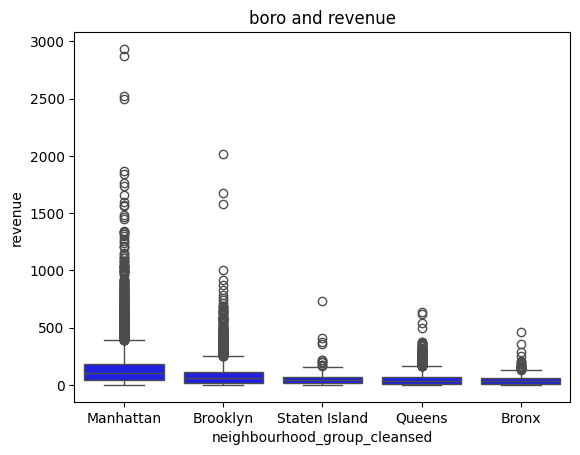

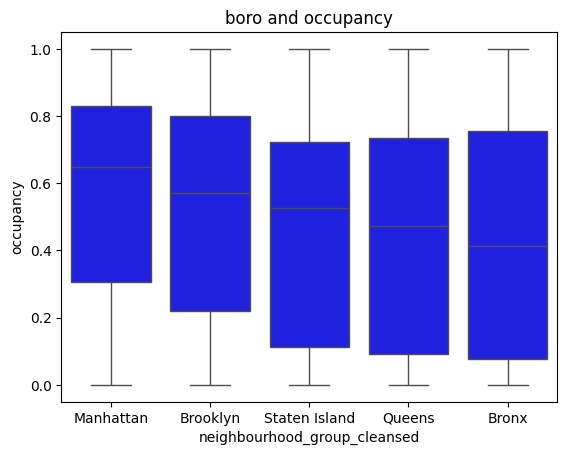

In [79]:
# Relationships between various columns and borough

sns.boxplot(data=ab, x='neighbourhood_group_cleansed', y='review_scores_rating', color='blue')
plt.title('boro and overall rating')
plt.show()

sns.boxplot(data=ab, x='neighbourhood_group_cleansed', y='review_scores_location', color='blue')
plt.title('boro and location score')
plt.show()

sns.boxplot(data=ab, x='neighbourhood_group_cleansed', y='revenue', color='blue')
plt.title('boro and revenue')
plt.show()

sns.boxplot(data=ab, x='neighbourhood_group_cleansed', y='occupancy', color='blue')
plt.title('boro and occupancy')
plt.show()

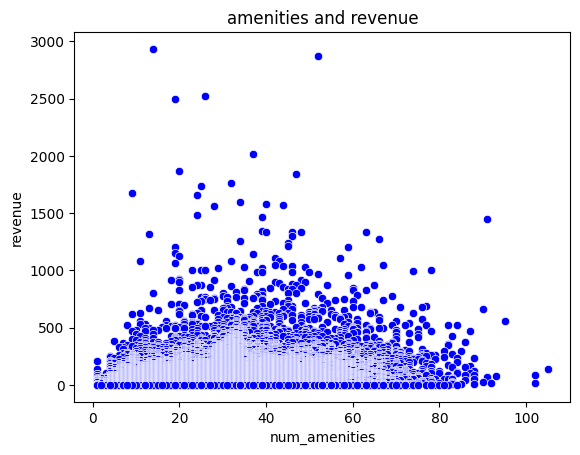

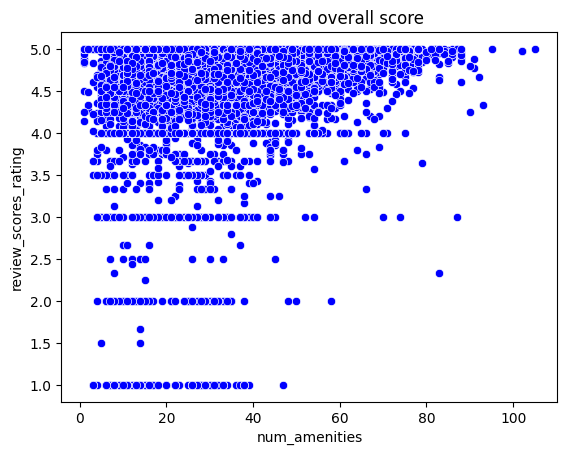

In [89]:
# amenities

sns.scatterplot(data=ab, x='num_amenities', y='revenue', color='blue')
plt.title('amenities and revenue')
# plt.yscale('log')
plt.show()

sns.scatterplot(data=ab, x='num_amenities', y='review_scores_rating', color='blue')
plt.title('amenities and overall score')
# plt.yscale('log')
plt.show()

In [ ]:
#| output-location: slide

## Conclusion / RESOLUTION